# GOES-19 mesoscale — a hurricane in four RGBs

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/geotoolz/blob/main/docs/products/notebooks/goes_mesoscale.ipynb)

You turn one GOES-19 one-minute mesoscale scan into the four standard RGB composites, a cloud mask and a parallax-corrected cloud field. The scan is sector M2 on 8 October 2026 at 18:00 UTC, centred on a hurricane in the Gulf of Mexico. Everything comes anonymously from NOAA's public `noaa-goes19` bucket.

**What you'll learn:**

1. Find and download ABI files with `geoproducts.goes.aws`.
2. Read three L2 products with `goes.L2Reader`: imagery (`MCMIP`), clear sky mask (`ACM`) and cloud-top height (`ACHA`).
3. Put them on one 2 km grid with `geoproducts.stack`.
4. Build the four RGB presets and a custom `gz.viz.RGBRecipe`.
5. Mask clouds with `goes.MaskClouds` and correct parallax with `goes.ParallaxCorrect`.

File formats, calibration and every product the readers handle are on the [GOES-R ABI page](../goes.md).

## Setup

On Colab the next cell installs `geotoolz-products[goes,operators]`; locally, use the workspace environment (`make install`).

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "geotoolz @ git+https://github.com/jejjohnson/geotoolz@main#subdirectory=packages/geotoolz",
            "geotoolz-cloud @ git+https://github.com/jejjohnson/geotoolz@main#subdirectory=packages/geotoolz-cloud",
            "geotoolz-products[goes,operators] @ git+https://github.com/jejjohnson/geotoolz@main#subdirectory=packages/geotoolz-products",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import tempfile
from datetime import datetime
from pathlib import Path

import geoproducts
import matplotlib.pyplot as plt
import numpy as np
from geoproducts import goes
from geoproducts.goes import aws
from georeader.geotensor import GeoTensor

import geotoolz as gz

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p numpy,matplotlib,h5py,georeader,geotoolz,geoproducts,geocloud",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.16
IPython version      : 9.13.0

numpy      : 2.4.5
matplotlib : 3.10.9
h5py       : 3.16.0
georeader  : unknown
geotoolz   : 0.9.0
geoproducts: 0.3.0
geocloud   : 0.3.0

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.18.44-fc-v80
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## 1. Find the scan

`aws.list_files` lists every ABI file whose scan starts in a time window, filtered by product and sector. Mesoscale L2 products end in `M` (`ABI-L2-MCMIPM`), and `sector="M2"` keeps the second mesoscale box. No AWS account is needed.

In [4]:
SLOT: datetime = datetime(2026, 10, 8, 18, 0)  # naive → UTC · 13:00 in the Gulf
SECTOR: str = "M2"  # the hurricane box that afternoon

found: dict[str, aws.ABIFile] = {}
for code in ("MCMIP", "ACM", "ACHA"):
    files: list[aws.ABIFile] = aws.list_files(
        satellite="G19",
        product=f"ABI-L2-{code}M",  # M = mesoscale
        sector=SECTOR,
        start=SLOT,
        end=datetime(2026, 10, 8, 18, 1),  # the first one-minute scan
    )
    found[code] = files[0]

for code, item in found.items():
    print(f"{code:5s} {item.start:%H:%M:%S}  {item.size / 1e6:5.2f} MB  {item.name}")

MCMIP 18:00:55   4.72 MB  OR_ABI-L2-MCMIPM2-M6_G19_s20262811800558_e20262811801021_c20262811801085.nc
ACM   18:00:55   0.26 MB  OR_ABI-L2-ACMM2-M6_G19_s20262811800558_e20262811801015_c20262811801121.nc
ACHA  18:00:55   0.24 MB  OR_ABI-L2-ACHAM2-M6_G19_s20262811800558_e20262811801015_c20262811801295.nc


`aws.download` streams each file into a directory and reuses one that is already there. Use a temporary directory, so nothing lands in your project.

In [5]:
DATA: Path = Path(tempfile.mkdtemp(prefix="goes-"))
paths: dict[str, Path] = {c: aws.download(item, DATA) for c, item in found.items()}
for path in paths.values():
    print(f"{path.stat().st_size / 1e6:5.2f} MB  {path.name}")

 4.72 MB  OR_ABI-L2-MCMIPM2-M6_G19_s20262811800558_e20262811801021_c20262811801085.nc
 0.26 MB  OR_ABI-L2-ACMM2-M6_G19_s20262811800558_e20262811801015_c20262811801121.nc
 0.24 MB  OR_ABI-L2-ACHAM2-M6_G19_s20262811800558_e20262811801015_c20262811801295.nc


## 2. Read three L2 products

`goes.L2Reader` opens any L2 file lazily on its `+proj=geos` fixed grid. Opening reads metadata only; pixels are decoded on `load()` or a window read. Note that ACHA comes on a 4 km grid, twice as coarse as the other two.

In [6]:
cmi: goes.L2Reader = goes.L2Reader(paths["MCMIP"])  # (16, 500, 500) float32
acm: goes.L2Reader = goes.L2Reader(paths["ACM"])  #   (2, 500, 500) uint8
acha: goes.L2Reader = goes.L2Reader(paths["ACHA"])  # (1, 250, 250) float32 · m

for r in (cmi, acm, acha):
    print(f"{r.product:5s} {r.shape} {r.dtype}  {r.transform.a:.0f} m  {r.bands[:3]}")
print(f"satellite longitude: {cmi.satellite_lon_deg}°")
print(acm.flags("ACM"))

MCMIP (16, 500, 500) float32  2004 m  ('C01', 'C02', 'C03')
ACM   (2, 500, 500) uint8  2004 m  ('BCM', 'ACM')
ACHA  (1, 250, 250) float32  4008 m  ('HT',)
satellite longitude: -75.2°
{0: 'clear', 1: 'probably_clear', 2: 'probably_cloudy', 3: 'cloudy'}


## 3. Put them on one grid

`geoproducts.stack` warps every reader onto the first one's grid. ACHA's 4 km heights are interpolated bilinearly; the integer masks are resampled with `mode`, so they stay class codes. The stack is `float32` with `NaN` fill because it mixes float and integer bands.

In [7]:
scene: GeoTensor = geoproducts.stack([cmi, acm, acha])  # (19, 500, 500) float32
print(scene.shape, scene.dtype)
print(scene.attrs["band_names"])

(19, 500, 500) float32
('C01', 'C02', 'C03', 'C04', 'C05', 'C06', 'C07', 'C08', 'C09', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'BCM', 'ACM', 'HT')


Two of the nineteen bands, now on one grid: the longwave brightness temperature and the cloud-top height.

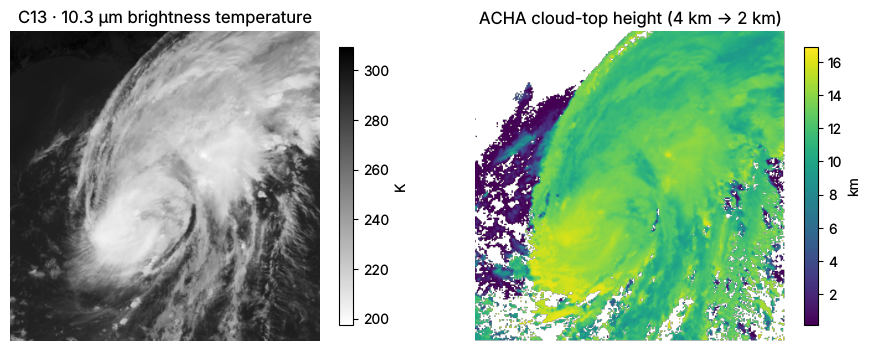

In [8]:
# Shapes: C = 19 bands, H × W = 500 × 500 pixels.
pick: gz.spectral.SelectBands = gz.spectral.SelectBands(bands=["C13", "HT"])
pair: np.ndarray = np.asarray(pick(scene))  # (C, H, W) → (2, H, W) float32
c13, ht = pair  # 2 × (H, W): K, m · NaN = clear

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, data, title, cmap, label in [
    (axes[0], c13, "C13 · 10.3 µm brightness temperature", "gray_r", "K"),
    (axes[1], ht / 1000, "ACHA cloud-top height (4 km → 2 km)", "viridis", "km"),
]:
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.8, label=label)
plt.show()

## 4. RGB recipes

Each preset turns the stack into a display RGB in `[0, 1]`, reading its channels by name. The recipes themselves are plain data in `goes.recipes`; the [RGB recipes table](../goes.md#rgb-recipes) says which channels each one reads.

In [9]:
for recipe in (
    goes.recipes.TRUE_COLOR,
    goes.recipes.NATURAL_COLOR,
    goes.recipes.DAY_CLOUD_PHASE,
    goes.recipes.FIRE_TEMPERATURE,
):
    print(f"{recipe.name:17s} R={recipe.red:4s} G={recipe.green:32s} B={recipe.blue}")

true_color        R=C02  G=0.45 * C02 + 0.1 * C03 + 0.45 * C01 B=C01
natural_color     R=C05  G=C03                              B=C02
day_cloud_phase   R=C13  G=C02                              B=C05
fire_temperature  R=C07  G=C06                              B=C05


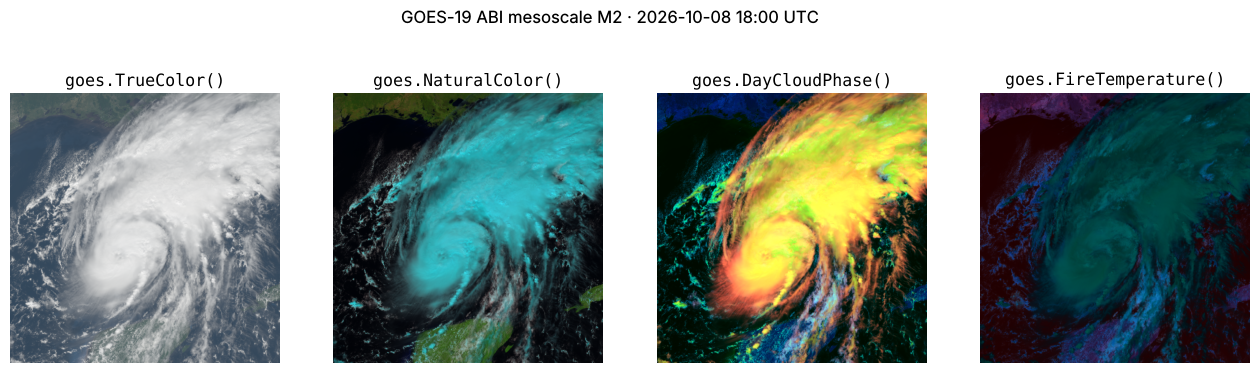

In [10]:
presets: dict[str, gz.Operator] = {
    "goes.TrueColor()": goes.TrueColor(),
    "goes.NaturalColor()": goes.NaturalColor(),
    "goes.DayCloudPhase()": goes.DayCloudPhase(),
    "goes.FireTemperature()": goes.FireTemperature(),
}
rgbs: dict[str, GeoTensor] = {n: op(scene) for n, op in presets.items()}  # (3, H, W)


def show_rgb(ax: plt.Axes, rgb: GeoTensor, title: str, nan: float = 0.0) -> None:
    """Draw a (3, H, W) RGB in [0, 1]; NaN pixels take the grey level ``nan``."""
    image: np.ndarray = np.moveaxis(np.asarray(rgb), 0, -1)  # (3, H, W) → (H, W, 3)
    ax.imshow(np.nan_to_num(image, nan=nan))
    ax.set_title(title, family="monospace")
    ax.set_axis_off()


fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (name, rgb) in zip(axes, rgbs.items(), strict=True):
    show_rgb(ax, rgb, name)
fig.suptitle(
    f"GOES-19 ABI mesoscale {SECTOR} · {found['MCMIP'].start:%Y-%m-%d %H:%M} UTC"
)
plt.show()

Day cloud phase shows the hurricane's cold, glaciated tops in red and yellow and the low liquid clouds around it in cyan. Fire temperature stays dark: no fires are burning in this box.

A preset is a configured operator, so `get_config()` shows the recipe behind it:

In [11]:
print(presets["goes.DayCloudPhase()"].get_config())

{'red': 'C13', 'green': 'C02', 'blue': 'C05', 'vmin': [280.65, 0.0, 0.01], 'vmax': [219.65, 0.78, 0.59], 'gamma': [1.0, 1.0, 1.0], 'axis': -3}


### A custom recipe

Any other composite is one `gz.viz.RGBRecipe`. The CIRA simple water vapour RGB inverts three infrared channels (`vmin > vmax`), so cold, moist air is bright. Dry air wrapping into the storm shows up dark.

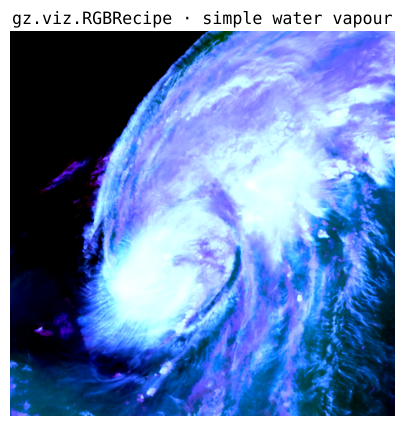

In [12]:
simple_wv: gz.viz.RGBRecipe = gz.viz.RGBRecipe(
    red="C13",
    green="C08",
    blue="C10",
    vmin=(278.96, 242.67, 261.03),  # K · above vmax → inverted
    vmax=(202.29, 214.66, 245.12),
)
wv: GeoTensor = simple_wv(scene)  # (C, H, W) → (3, H, W) float32

fig, ax = plt.subplots(figsize=(5, 5))
show_rgb(ax, wv, "gz.viz.RGBRecipe · simple water vapour")
plt.show()

## 5. Mask clouds

`goes.MaskClouds()` returns `True` where the clear sky mask says cloudy. `conservative=True` also drops *probably clear* pixels.

In [13]:
mask_op: gz.Operator = goes.MaskClouds()
strict_op: gz.Operator = goes.MaskClouds(conservative=True)

cloudy: GeoTensor = mask_op(scene)  #   (C, H, W) → (H, W) bool · True = cloud
strict: GeoTensor = strict_op(scene)  # (C, H, W) → (H, W) bool

print(f"cloudy {np.mean(cloudy):.1%} · conservative {np.mean(strict):.1%}")

cloudy 84.0% · conservative 85.0%


`gz.mask.ApplyMask` blanks the masked pixels in every band. Select the bands you need first: a pixel with `NaN` in any band counts as no data, and `HT` is `NaN` under clear sky. A `Sequential` chains the three steps:

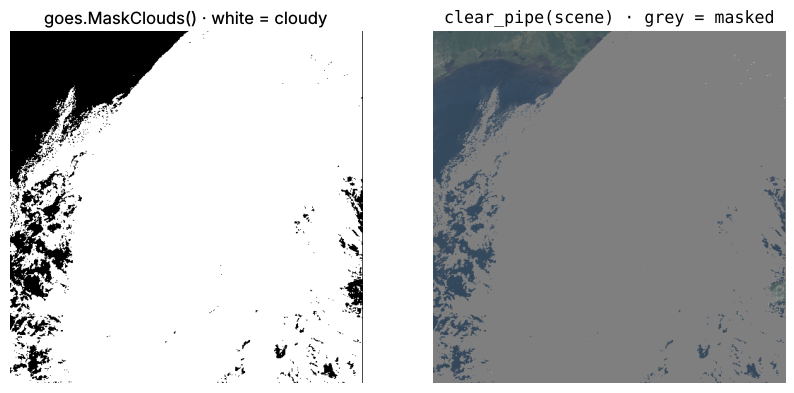

In [14]:
keep: gz.spectral.SelectBands = gz.spectral.SelectBands(
    bands=["C01", "C02", "C03", "BCM"]
)
clear_pipe: gz.Sequential = (
    keep | gz.mask.ApplyMask(mask=goes.MaskClouds()) | goes.TrueColor()
)
clear_rgb: GeoTensor = clear_pipe(scene)  # (C, H, W) → (3, H, W) float32 · cloud = NaN

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(np.asarray(cloudy), cmap="gray")
axes[0].set_title("goes.MaskClouds() · white = cloudy")
axes[0].set_axis_off()
show_rgb(axes[1], clear_rgb, "clear_pipe(scene) · grey = masked", nan=0.5)
plt.show()

## 6. Correct parallax

`goes.ParallaxCorrect` moves each cloud top back over the ground it sits above. A geostationary satellite sees a high cloud displaced away from the sub-satellite point (75.2°W on the equator). For a 15 km hurricane top at 25°N that is several pixels.

The operator works on an EPSG:4326 grid and takes the cloud-top height per pixel. Reproject the stack first, then pick C13 and the height:

In [15]:
# Shapes: h × w = lon/lat pixels at 0.02°.
to_lonlat: gz.geom.Reproject = gz.geom.Reproject(
    dst_crs="EPSG:4326", resolution=(0.02, 0.02)
)
select_c13: gz.spectral.SelectBands = gz.spectral.SelectBands(bands=["C13"])
select_ht: gz.spectral.SelectBands = gz.spectral.SelectBands(bands=["HT"])

lonlat: GeoTensor = to_lonlat(scene)  #               (C, H, W) → (C, h, w) float32
bt: GeoTensor = select_c13(lonlat)  #                 (C, h, w) → (1, h, w) float32, K
height: GeoTensor = select_ht(lonlat)  #              (C, h, w) → (1, h, w) float32, m
cloud_top: np.ndarray = np.asarray(height)[0]  #      (1, h, w) → (h, w) float32, m
cloud_top_m: np.ndarray = np.nan_to_num(cloud_top)  # (h, w) · clear NaN → 0 m
print(lonlat.shape, lonlat.crs)

parallax: gz.Operator = goes.ParallaxCorrect(
    satellite_lon_deg=cmi.satellite_lon_deg,  # -75.2 for GOES-East
    target_height_m=cloud_top_m,
)
moved: GeoTensor = parallax(bt)  # (1, h, w) → (1, h, w) float32, K

(19, 546, 616) EPSG:4326


The difference image lights up the cloud edges that moved. Clouds shift towards the satellite, to the south-east here.

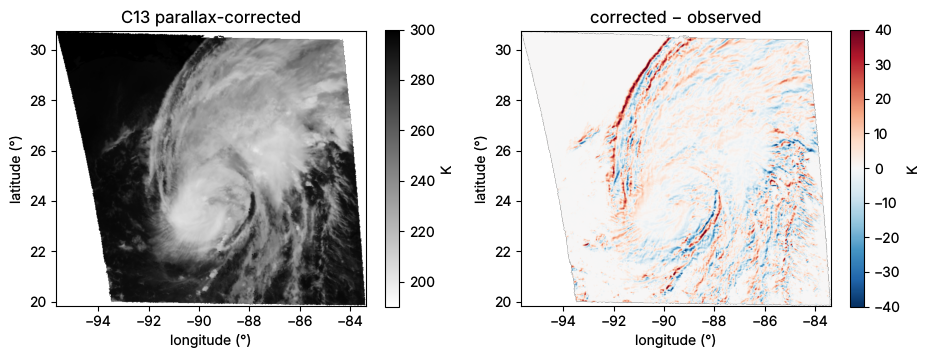

In [16]:
extent: tuple[float, float, float, float] = (
    lonlat.bounds[0],
    lonlat.bounds[2],
    lonlat.bounds[1],
    lonlat.bounds[3],
)
before: np.ndarray = np.asarray(bt)[0]  #   (1, h, w) → (h, w) float32
after: np.ndarray = np.asarray(moved)[0]  # (1, h, w) → (h, w) float32

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im = axes[0].imshow(after, cmap="gray_r", extent=extent, vmin=190, vmax=300)
axes[0].set_title("C13 parallax-corrected")
fig.colorbar(im, ax=axes[0], shrink=0.8, label="K")
im = axes[1].imshow(after - before, cmap="RdBu_r", extent=extent, vmin=-40, vmax=40)
axes[1].set_title("corrected − observed")
fig.colorbar(im, ax=axes[1], shrink=0.8, label="K")
for ax in axes:
    ax.set_xlabel("longitude (°)")
    ax.set_ylabel("latitude (°)")
plt.show()

## Summary

- `goes.aws.list_files` and `download` fetch any ABI product from NOAA's anonymous buckets.
- `goes.L2Reader` opens L2 products lazily; `geoproducts.stack` puts different resolutions on one grid and keeps mask codes intact.
- The four presets build the operational RGBs; `gz.viz.RGBRecipe` builds any other.
- `goes.MaskClouds` and `goes.ParallaxCorrect` turn the ACM and ACHA products into a cloud mask and a parallax correction.

Next: the same workflow on Himawari-9 in [Himawari-9 over Japan](himawari_japan.ipynb), and the reader reference on the [GOES-R ABI page](../goes.md).